<a href="https://colab.research.google.com/github/MuhamedRagabbb/DEEP_LEARNING_PROJECTS/blob/main/tutorial3_SimpleNeuralNetwork.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
# Inheriting from nn.Module registers this class with PyTorch
# (enables GPU support, automatic gradient tracking, and saving weights)
class MODEL(nn.Module):
  def __init__(self,in_features=4, h1=8,h2=8,output=3):
    super().__init__() # Always call super().__init__() to properly initialize PyTorch's base class

    # [Define Layers] Define layers with their input and output dimensions

    self.fc1=nn.Linear(in_features,h1)# Layer 1: 4 inputs -> 8 hidden units

    self.fc2=nn.Linear(h1,h2)# Layer 2: 8 hidden units -> 8 hidden units

    self.out=nn.Linear(h2,output)# Output Layer: 8 hidden units -> 3 classes

  # [Define Data Flow] Called automatically when you pass data to the model: model(x)
  def forward(self ,x):

    # Pass input through layer 1, then apply ReLU to add non-linearity
    x = F.relu(self.fc1(x))

    # Pass through layer 2, then apply ReLU
    x=F.relu(self.fc2(x))

    # Output layer (no activation function applied here to return raw logits)
    x=self.out(x)

    return x

In [ ]:
# pick a manual seed for randomization دي علشان اثبت العشوائيه
torch.manual_seed(41)
# create our instance
# Re-instantiate the model after the class definition was fixed.
model=MODEL()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
url ='https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/0e7a9b0a5d22642a06d3d5b9bcbad9890c8ee534/iris.csv'
df=pd.read_csv(url)
df.tail()

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


In [ ]:
df['species']=df['species'].replace("setosa",0.0)
df['species']=df['species'].replace("versicolor",1.0)
df['species']=df['species'].replace("virginica",2.0)

/tmp/ipykernel_749/1301004896.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['species']=df['species'].replace("virginica",2.0)


In [ ]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0


In [ ]:
# train test split make x ,y
x=df.drop('species',axis=1)
y=df['species']

In [ ]:
x

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [ ]:
y

,species
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
145,2.0
146,2.0
147,2.0
148,2.0


In [ ]:
# convert to numpy arrays
x=x.values
y=y.values

In [ ]:
x

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=41)

In [ ]:
#convert to tensors
x_train=torch.FloatTensor(x_train)
x_test=torch.FloatTensor(x_test)
y_train=torch.LongTensor(y_train) # Re-running this cell after fixing train_test_split will update y_train to correct size
y_test=torch.LongTensor(y_test)

In [ ]:
#set the criterion
criterion=nn.CrossEntropyLoss()
# lr , adam optimizer
optimizer=torch.optim.Adam(model.parameters(),lr=0.01)

In [ ]:
model.parameters

<bound method Module.parameters of MODEL(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=8, bias=True)
  (out): Linear(in_features=8, out_features=3, bias=True)
)>

In [ ]:
#train
epochs=100
losses=[]
for i in range(epochs):
  y_pred=model.forward(x_train)

  loss=criterion(y_pred,y_train)
  losses.append(loss)

  if i %10 == 0:
    print(f"epoch {i} and the loss is {loss}")


  optimizer.zero_grad()
  loss.backward()
  optimizer.step()


epoch 0 and the loss is 1.1318050622940063
epoch 10 and the loss is 0.9658581614494324
epoch 20 and the loss is 0.6791526675224304
epoch 30 and the loss is 0.40087202191352844
epoch 40 and the loss is 0.22570070624351501
epoch 50 and the loss is 0.12255845963954926
epoch 60 and the loss is 0.07509137690067291
epoch 70 and the loss is 0.05467576906085014
epoch 80 and the loss is 0.04448389261960983
epoch 90 and the loss is 0.03846167027950287


Text(0.5, 0, 'epochs')

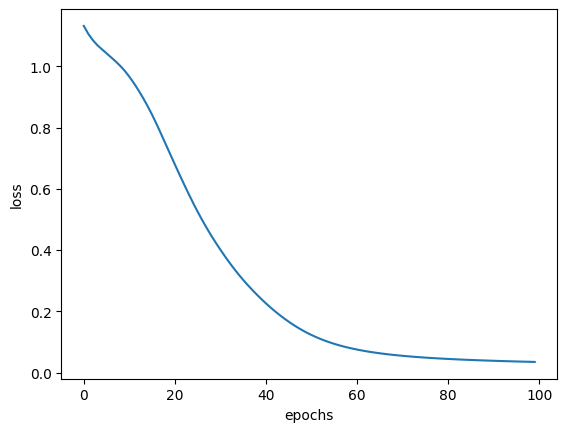

In [ ]:
plt.plot(range(epochs), [loss.detach().numpy() for loss in losses])
plt.ylabel("loss")
plt.xlabel("epochs")